# Modelos a integrar en el dataset

Una vez definidos los métodos de optimización y de balanceo, se procederá a utilizarlos con los modelos seleccionados para ser integrados dentro del dataset, con el motivo de experimentar su eficiencia en campos donde su aplicación no ha sido común según la investigación realizada. Con el fin de realizar esto se hará una modificación del pipeline de optimización original para que ejecute únicamente el método de optimización 'Random_Search' junto al método de balanceo por peso 'Weights':


In [9]:
#Importado de bibliotecas 

import warnings
warnings.filterwarnings('ignore')

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

#Bibliotecas varias
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from scipy.stats import loguniform, uniform, randint

#Scikit-learn (incluye Grid y Random Search)
from sklearn.model_selection import cross_validate
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, f1_score, balanced_accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

#Optimización Bayesiana con Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#Algoritmos Genéticos con DEAP
from deap import base, creator, tools, algorithms
import operator

#Elementos para reproducibilidad global IMPORTANTE
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Entorno configurado correctamente")
print(f"   NumPy:      {np.__version__}")
print(f"   Pandas:     {pd.__version__}")
print(f"   Scikit-learn: importado")
print(f"   XGBoost:    {xgb.__version__}")
print(f"   Optuna:     {optuna.__version__}")
print(f"   RANDOM_STATE = {RANDOM_STATE}")

Entorno configurado correctamente
   NumPy:      1.26.4
   Pandas:     2.3.3
   Scikit-learn: importado
   XGBoost:    2.1.4
   Optuna:     4.8.0
   RANDOM_STATE = 42


In [10]:
df_limpio = pd.read_csv('df_limpio.csv')

df_final = df_limpio[df_limpio["Estado"].isin(["Leve", "Fallecido"])].copy()

column_rename = {
    'fecha reporte web'           : 'fecha_reporte',
    'Fecha de notificación'       : 'fecha_notificacion',
    'Código DIVIPOLA municipio'   : 'municipio_cod',
    'Edad'                        : 'edad',
    'Unidad de medida de edad'    : 'unidad_edad',
    'Sexo'                        : 'sexo',
    'Tipo de contagio'            : 'tipo_contagio',
    'Ubicación del caso'          : 'ubicacion',
    'Estado'                      : 'estado',
    'Recuperado'                  : 'recuperado',
    'Fecha de inicio de síntomas' : 'fecha_sintomas',
    'Fecha de diagnóstico'        : 'fecha_diagnostico',
    'Fecha de recuperación'       : 'fecha_recuperacion',
    'Tipo de recuperación'        : 'tipo_recuperacion',
    'Pertenencia étnica'          : 'etnia'
}

df_final = df_final.rename(columns=column_rename)
print(f"Filas tras filtrar Leve/Fallecido: {df_final.shape[0]:,}")

df_final.head()

Filas tras filtrar Leve/Fallecido: 419,023


,fecha_reporte,fecha_notificacion,municipio_cod,edad,unidad_edad,sexo,tipo_contagio,ubicacion,estado,recuperado,fecha_sintomas,fecha_diagnostico,fecha_recuperacion,tipo_recuperacion,etnia
0,2021-01-13,2020-12-27,8758,75,1,M,Comunitaria,Casa,Leve,Recuperado,2020-12-25,2021-01-07,2021-01-14,Tiempo,6.0
1,2020-07-18,2020-06-30,8758,52,1,F,Comunitaria,Casa,Leve,Recuperado,2020-06-28,2020-07-11,2020-07-27,Tiempo,6.0
2,2020-09-23,2020-09-11,8758,80,1,F,Comunitaria,Casa,Leve,Recuperado,2020-09-09,2020-09-22,2020-09-28,Tiempo,6.0
3,2020-07-18,2020-07-01,8634,21,1,F,Comunitaria,Casa,Leve,Recuperado,2020-06-29,2020-07-12,2020-07-26,Pcr,6.0
4,2020-07-18,2020-06-30,8758,15,1,F,Comunitaria,Casa,Leve,Recuperado,2020-06-28,2020-07-11,2020-07-27,Pcr,6.0


In [11]:
#Paso 1: Feature Engineering

#Convertir fechas utilizando pandas para facilitar la manipulación
for col in ['fecha_notificacion', 'fecha_sintomas', 'fecha_diagnostico']:
    df_final[col] = pd.to_datetime(df_final[col], errors='coerce')
    

#Se establece una nueva variable que nos diga los Días entre inicio de síntomas y diagnóstico (lag diagnóstico)
df_final['dias_hasta_diagnostico'] = (df_final['fecha_diagnostico'] - df_final['fecha_sintomas']).dt.days.clip(0, 60) #Intervalo en 60 días para datos Atípicos 


#Establecer la edad en años (la columna unidad_edad puede indicar meses o días)
def normalizar_edad(row):
    if row['unidad_edad'] == 2:   #meses
        return row['edad'] / 12
    elif row['unidad_edad'] == 3: #días
        return row['edad'] / 365
    return row['edad']

df_final['edad_años'] = df_final.apply(normalizar_edad, axis=1).clip(0, 120)

#Para mejor percepción del modelo se crea una variable que contenga Grupos de edad
bins = [0, 18, 40, 60, 75, 120]
labels_age = ['0-18', '19-40', '41-60', '61-75', '75+']
df_final['grupo_edad'] = pd.cut(df_final['edad_años'], bins=bins, labels=labels_age, right=True)

#Se guarda el mes del año para tener en cuenta estacionalidad pandémica
df_final['mes_notificacion'] = df_final['fecha_notificacion'].dt.month

#Se transformaa en str los codigos de cada municipio para aplicar OneHotEncoding
df_final['municipio_cod'] = df_final['municipio_cod'].astype(str)

#Eliminar las etnias con menor número de apariciones en el dataset
grupos_minoritarios = df_final['etnia'].value_counts()
grupos_minoritarios = grupos_minoritarios[grupos_minoritarios < 500].index

#Luego Agrupas
df_final = df_final[~df_final['etnia'].isin(grupos_minoritarios)]
df_final['etnia'] = df_final['etnia'].astype(str)
df_final = df_final.reset_index(drop=True)

print("Features construidas:")
print("dias_hasta_diagnostico, edad_años, grupo_edad, mes_notificacion")
print("")
print("Features modificadads:")
print("municipio cod, etnia")


Features construidas:
dias_hasta_diagnostico, edad_años, grupo_edad, mes_notificacion

Features modificadads:
municipio cod, etnia


In [12]:
#PASO 2: SELECCIÓN de variables para el modelado

FEATURES_NUM = [
    'edad_años',
    'dias_hasta_diagnostico',
    'mes_notificacion'
    
]

FEATURES_CAT = [
    'sexo',
    'tipo_contagio',
    'grupo_edad',
    'etnia',
    'municipio_cod'
]

#Se codifica la variable objetivo 'estado', donde los casos leves se representan con 0, y los fatales con 1
df_final['estado_bin'] = (df_final['estado'].str.upper() == 'FALLECIDO').astype(int)
TARGET = 'estado_bin'

FEATURES_ALL = FEATURES_NUM + FEATURES_CAT

#Se crea una copia limpia que contenga unicamente la información de las variables que seleccionamos
datos = df_final[FEATURES_ALL + [TARGET]].copy()
datos = datos.dropna(subset=[TARGET])

#Se dividen para el entrenamiento
X = datos[FEATURES_ALL]
y = datos[TARGET].astype(int)

print(f"Dimensiones: {X.shape}")
datos.head()

Dimensiones: (419016, 8)


,edad_años,dias_hasta_diagnostico,mes_notificacion,sexo,tipo_contagio,grupo_edad,etnia,municipio_cod,estado_bin
0,75.0,13.0,12,M,Comunitaria,61-75,6.0,8758,0
1,52.0,13.0,6,F,Comunitaria,41-60,6.0,8758,0
2,80.0,13.0,9,F,Comunitaria,75+,6.0,8758,0
3,21.0,13.0,7,F,Comunitaria,19-40,6.0,8634,0
4,15.0,13.0,6,F,Comunitaria,0-18,6.0,8758,0


In [13]:
#Paso 3: Pre-procesamiento con ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  FEATURES_NUM),
        ('cat', categorical_transformer, FEATURES_CAT)
    ],
    remainder='drop'
)

print("Preprocesador definido (ColumnTransformer)")
print("Numérico:    Imputer(mediana) → StandardScaler")
print("Categórico:  Imputer(moda)   → OneHotEncoder")

Preprocesador definido (ColumnTransformer)
Numérico:    Imputer(mediana) → StandardScaler
Categórico:  Imputer(moda)   → OneHotEncoder


In [14]:
#Paso 4: Train/Test Split estratificado

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y          #estratificado
)

print(f"Split estratificado: 80% Entrenamiento (Train) y 20% Prueba (Test)")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

#Se verifica que se mantenga la proporción:
print("\nDistribución en train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nDistribución en test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Split estratificado: 80% Entrenamiento (Train) y 20% Prueba (Test)
Train: 335,212 | Test: 83,804

Distribución en train:
estado_bin
0    0.97
1    0.03
Name: proportion, dtype: float64

Distribución en test:
estado_bin
0    0.97
1    0.03
Name: proportion, dtype: float64


In [15]:
#Paso 5: Validación cruzada

from sklearn.metrics import fbeta_score, make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'recall' #Acá está la métrica recall para el entrenamiento
SCORING_MULTIPLE = {
    'pr_auc'  : 'average_precision',
    'roc_auc' : 'roc_auc',
    'f1'      : 'f1',
    'recall'  : 'recall',
    'precision': 'precision',
    'balanced_accuracy': 'balanced_accuracy'
}

print(f"Validación: StratifiedKFold (k=5, shuffle=True, seed={RANDOM_STATE})")
print(f"Métrica de optimización: {SCORING}")

Validación: StratifiedKFold (k=5, shuffle=True, seed=42)
Métrica de optimización: recall


In [34]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN


# ─────────────────────────────────────────────
# PIPELINE DE OPTIMIZACIÓN CON BALANCEO
# ─────────────────────────────────────────────

#Aqui arranca el pipeline, y acá están los métodos de balanceo, el único que va a cambiar de modelo a modelo
# es el weights

# ─────────────────────────────────────────────
# CONFIGURACIÓN DE BALANCEADORES
# ─────────────────────────────────────────────
BALANCEADORES = {
    'sin_balanceo': None,
    'weights'     : 'weights'
}


def optimizar_modelo_b(
    nombre_modelo,
    make_pipeline_fn,   # ahora recibe (params=None, balancer=None)
    param_grid,
    param_dist,
    objective_fn_factory,  # factory: recibe balancer → retorna objective_fn
    gene_bounds,
    decode_fn,
    param_grid_weights = None,   #Paramétro para seleccionar si se usa el método de pesos
    param_dist_weights = None,
    X_train_override   = None,   #Solo se rellena si se usa la muestra
    y_train_override   = None,   #Solo se rellena si se usa la muestra
    gene_bounds_weights= None,   #Parametros extra para cuando se haga balanceo por peso con RIdge Y lasso
    decode_fn_weights  = None,   #Especificamente para DEAP
):
    """
    Por cada método de optimización, ejecuta los 4 métodos de balanceo.
    Estructura de resultados:
      resultados[metodo][nombre_balanceo] = {score_cv, tiempo, params, estimator, ...}
    """
    
    #Validación de si usa muestra o el dataset entero
    X_tr = X_train_override if X_train_override is not None else X_train
    y_tr = y_train_override if y_train_override is not None else y_train

    
    resultados = {'modelo': nombre_modelo}

    #Inicializar estructura por método
    for metodo in ['baseline', 'grid_search', 'random_search', 'optuna', 'deap']:
        resultados[metodo] = {}

    print(f"\n{'='*60}")
    print(f"  OPTIMIZANDO: {nombre_modelo}")
    print(f"{'='*60}")

    for nombre_bal, balancer in BALANCEADORES.items():

        print(f"\n{'─'*60}")
        print(f"  BALANCEO: {nombre_bal.upper()}")
        print(f"{'─'*60}")

        
        pg = param_grid_weights if (nombre_bal == 'weights' and param_grid_weights) else param_grid
        pd = param_dist_weights if (nombre_bal == 'weights' and param_dist_weights) else param_dist
        
        #Seleccionar gene_bounds y decode_fn según balanceador
        gb  = gene_bounds_weights  if (nombre_bal == 'weights' and gene_bounds_weights) else gene_bounds
        dfn = decode_fn_weights    if (nombre_bal == 'weights' and decode_fn_weights)   else decode_fn

 
        
        #make_pipe encapsula el balanceador actual
        make_pipe = lambda params=None, b=balancer: make_pipeline_fn(
            params=params, balancer=b
        )
        # ── 1. BASELINE ──────────────────────────────────────
        print(f"\n  [1/2] Baseline...")
        start = time.time()

        baseline_pipe = make_pipe()

        baseline_scores = cross_validate(
            baseline_pipe, X_tr, y_tr,
            cv=CV,
            scoring=SCORING_MULTIPLE,
            n_jobs=-1
        )

        metrics_cv = {
            k.replace('test_', ''): np.mean(v)
            for k, v in baseline_scores.items()
            if k.startswith('test_')
        }

        std_cv = {
            k.replace('test_', ''): np.std(v)
            for k, v in baseline_scores.items()
            if k.startswith('test_')
        }

        # Entrenar baseline final para test
        start_train = time.time()
        baseline_pipe.fit(X_tr, y_tr)
        tiempo_train_bl = time.time() - start_train

        start_pred = time.time()

        y_prob_bl = baseline_pipe.predict_proba(X_test)[:, 1]
        y_pred_bl = baseline_pipe.predict(X_test)

        tiempo_pred_bl = time.time() - start_pred

        resultados['baseline'][nombre_bal] = {
            'score_cv'      : metrics_cv['recall'],
            'std_cv'        : std_cv['recall'],
            'metrics_cv'    : metrics_cv,
            'tiempo'        : time.time() - start,
            'tiempo_train'  : tiempo_train_bl,
            'tiempo_pred'   : tiempo_pred_bl,
            'params'        : {},
            'estimator'     : baseline_pipe,

            # métricas test
            'recall_test'   : recall_score(y_test, y_pred_bl),
            'precision_test': precision_score(y_test, y_pred_bl, zero_division=0),
            'f1_test'       : f1_score(y_test, y_pred_bl),
            'roc_auc_test'  : roc_auc_score(y_test, y_prob_bl),
            'pr_auc_test'   : average_precision_score(y_test, y_prob_bl),
            'bal_acc_test'  : balanced_accuracy_score(y_test, y_pred_bl),
        }
        print(
            f"RECALL CV: "
            f"{resultados['baseline'][nombre_bal]['score_cv']:.4f} "
            f"± {resultados['baseline'][nombre_bal]['std_cv']:.4f} | "
            f"{resultados['baseline'][nombre_bal]['tiempo']:.1f}s"
        )

        metrics = resultados['baseline'][nombre_bal]['metrics_cv']

        print(
            " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()])
        )

        # ── 3. RANDOM SEARCH ─────────────────────────────────
        print(f"\n  [2/2] Random Search...")
        start = time.time()
        rs = RandomizedSearchCV(
            estimator           = make_pipe(),
            param_distributions = pd,
            n_iter              = 20,
            cv                  = CV,
            scoring             = SCORING_MULTIPLE,
            n_jobs              = -1,
            refit               = 'recall',
            random_state        = RANDOM_STATE,
            verbose             = 0
        )
        rs.fit(X_tr, y_tr)
        resultados['random_search'][nombre_bal] = {
            'score_cv' : rs.best_score_,
            'tiempo'   : time.time() - start,
            'tiempo_train'  : time.time() - start,
            'params'   : rs.best_params_,
            'estimator': rs.best_estimator_
        }
        
        cv_results = rs.cv_results_

        resultados['random_search'][nombre_bal]['metrics_cv'] = {
            'recall'  : rs.best_score_,
            'pr_auc'  : cv_results['mean_test_pr_auc'][rs.best_index_],
            'roc_auc' : cv_results['mean_test_roc_auc'][rs.best_index_],
            'balanced_accuracy': cv_results['mean_test_balanced_accuracy'][rs.best_index_],
            'precision': cv_results['mean_test_precision'][rs.best_index_],
            'f1': cv_results['mean_test_f1'][rs.best_index_],
        }
        
        print(f"RECALL CV: {rs.best_score_:.4f} | {resultados['random_search'][nombre_bal]['tiempo']:.1f}s")
        metrics = resultados['random_search'][nombre_bal]['metrics_cv']

        print(
            " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()])
        )

        # ── EVALUACIÓN EN TEST ────────────────────────────────
        print(f"\n  {'─'*40}")
        print(f"  TEST SET — {nombre_bal.upper()}")
        print(f"  {'─'*40}")

        for metodo in ['baseline', 'random_search']:

            est = resultados[metodo][nombre_bal]['estimator']
            
            start_pred = time.time()

            y_prob = est.predict_proba(X_test)[:, 1]
            y_pred = est.predict(X_test)
            
            tiempo_pred_rs = time.time() - start_pred

            resultados[metodo][nombre_bal]['recall_test'] = recall_score(y_test, y_pred)

            resultados[metodo][nombre_bal]['precision_test'] = precision_score(
                y_test,
                y_pred,
                zero_division=0
            )

            resultados[metodo][nombre_bal]['f1_test'] = f1_score(
                y_test,
                y_pred
            )

            resultados[metodo][nombre_bal]['bal_acc_test'] = balanced_accuracy_score(
                y_test,
                y_pred
            )

            resultados[metodo][nombre_bal]['pr_auc_test'] = average_precision_score(
                y_test,
                y_prob
            )

            resultados[metodo][nombre_bal]['roc_auc_test'] = roc_auc_score(
                y_test,
                y_prob
            )

            resultados[metodo][nombre_bal]['report'] = classification_report(
                y_test,
                y_pred,
                target_names=['Leve', 'Fallecido'],
                output_dict=True
            )
            
            resultados[metodo][nombre_bal]['tiempo_pred'] = tiempo_pred_rs

            print(
                f"  {metodo:<15} "
                f"PR-AUC: {resultados[metodo][nombre_bal]['pr_auc_test']:.4f} | "
                f"Recall: {resultados[metodo][nombre_bal]['recall_test']:.4f}"
            )

    return resultados

In [31]:
import time
from pathlib import Path

# ─────────────────────────────────────────────
# SISTEMA DE GUARDADO DE RESULTADOS SOTA
# ─────────────────────────────────────────────

REPO_RESULTADOS = {}

def guardar_resultados_modelo(resultados, repo, path='resultados_ml_covid_sota.csv'):
    nombre_modelo = resultados.get('modelo', 'desconocido')
    METODOS = ['baseline', 'grid_search', 'random_search', 'optuna', 'deap']
    BALANCEADORES_ORDEN = ['sin_balanceo', 'smote', 'adasyn', 'weights']
    filas = []

    for metodo in METODOS:
        bloque_metodo = resultados.get(metodo, {})
        for bal in BALANCEADORES_ORDEN:
            bloque = bloque_metodo.get(bal)
            if bloque is None:
                continue

            metrics_cv = bloque.get('metrics_cv', {})
            
            fila = {
                'modelo'              : nombre_modelo,
                'metodo'              : metodo,
                'balanceo'            : bal,
                'tiempo_total_s'      : round(bloque.get('tiempo', np.nan), 2),
                'tiempo_train_s'      : round(bloque.get('tiempo_train', np.nan), 2),
                'tiempo_pred_s'       : round(bloque.get('tiempo_pred', np.nan), 2),
                'params'              : str(bloque.get('params', {})),
                # CV
                'recall_cv'           : metrics_cv.get('recall', np.nan),
                'recall_cv_std'       : bloque.get('std_cv', np.nan),
                'precision_cv'        : metrics_cv.get('precision', np.nan),
                'f1_cv'               : metrics_cv.get('f1', np.nan),
                'balanced_accuracy_cv': metrics_cv.get('balanced_accuracy', np.nan),
                'pr_auc_cv'           : metrics_cv.get('pr_auc', np.nan),
                'roc_auc_cv'          : metrics_cv.get('roc_auc', np.nan),
                # Test
                'recall_test'         : bloque.get('recall_test', np.nan),
                'precision_test'      : bloque.get('precision_test', np.nan),
                'f1_test'             : bloque.get('f1_test', np.nan),
                'balanced_accuracy_test': bloque.get('bal_acc_test', np.nan),
                'pr_auc_test'         : bloque.get('pr_auc_test', np.nan),
                'roc_auc_test'        : bloque.get('roc_auc_test', np.nan),
            }
            filas.append(fila)

    col_order = [
        'modelo', 'metodo', 'balanceo',
        'recall_cv', 'recall_cv_std', 'precision_cv', 'f1_cv',
        'balanced_accuracy_cv', 'pr_auc_cv', 'roc_auc_cv',
        'recall_test', 'precision_test', 'f1_test',
        'balanced_accuracy_test', 'pr_auc_test', 'roc_auc_test',
        'tiempo_total_s', 'tiempo_train_s', 'tiempo_pred_s', 'params'
    ]

    df = pd.DataFrame(filas, columns=col_order)
    repo[nombre_modelo] = df

    # ── Guardar/actualizar CSV acumulado ──────────────────────
    if Path(path).exists():
        df_existente = pd.read_csv(path)
        df_existente = df_existente[df_existente['modelo'] != nombre_modelo]
        df_final_csv = pd.concat([df_existente, df], ignore_index=True)
    else:
        df_final_csv = df

    df_final_csv.to_csv(path, index=False)

    print(f"\n{'═'*60}")
    print(f"  ✓ Guardado: '{nombre_modelo}' — {len(df)} combinaciones")
    print(f"  ✓ CSV actualizado → {path}")
    print(f"{'═'*60}")
    top = (df[df['recall_cv'].notna()]
           .sort_values('recall_cv', ascending=False)
           .head(5)[['metodo', 'balanceo', 'recall_cv', 'pr_auc_cv', 'recall_test', 'pr_auc_test']])
    print("\n  TOP 5 por Recall CV:")
    print(top.to_string(index=False))
    return df


def resumen_general(repo):
    df_all = pd.concat(repo.values(), ignore_index=True)
    idx = df_all.groupby('modelo')['recall_cv'].idxmax()
    df_best = df_all.loc[idx, [
        'modelo', 'metodo', 'balanceo',
        'recall_cv', 'pr_auc_cv', 'roc_auc_cv',
        'recall_test', 'pr_auc_test', 'roc_auc_test'
    ]].sort_values('recall_cv', ascending=False)
    print("\nMEJOR combinación por modelo:")
    display(df_best)
    return df_all


print("Sistema de guardado SOTA listo.")

Sistema de guardado SOTA listo.


Como resultado, el nuevo pipeline ejecutará el ciclo con el método de balanceo 'weights' y el método de balanceo base, es decir, sin balanceo, junto con el modelo sin optimizar hiperparámetros 'baseline' y el método de optimización 'Random_Search'.

## LightGBM-Cost Sensitive
LightGBM (Light Gradient Boosting Machine) es un algoritmo de boosting basado en arboles de decision que fue disenado para ser muy rapido y eficiente con datasets grandes. A diferencia de XGBoost, LightGBM crece los arboles hoja por hoja en lugar de nivel por nivel, lo que lo hace mas eficiente en memoria y velocidad sin perder precision.

Por que sirve para nuestro problema: LightGBM tiene un parametro llamado scale_pos_weight que permite asignarle mas peso a la clase minoritaria durante el entrenamiento. Con un ratio de 32:1, se le podria asignar ese peso a los casos de Fallecido para que el modelo no los ignore. Yalcin et al. (G9) demostraron que LightGBM con SMOTE logra 99% de accuracy en clasificacion medica con desbalanceo, superando a SVM, KNN y Gradient Boosting. Adicionalmente, con 419.016 registros, LightGBM es mucho mas rapido que otros modelos para entrenar. La busqueda de verificacion en WoS con COVID-19, LightGBM y cost-sensitive dio 0 resultados, lo que confirma que no se ha explorado esta combinacion especifica para prediccion de mortalidad por COVID-19.

Para la implementación de LightGBM dentro del pipeline de optimización, se construye un clasificador LGBMClassifier configurado con boosting_type='gbdt' y objective='binary', donde el parámetro num_leaves reemplaza a max_depth como controlador principal de la complejidad del árbol dado el crecimiento leaf-wise característico del algoritmo. El manejo del desbalanceo se realiza mediante scale_pos_weight, que se fija en el ratio natural n_leve/n_fallecido cuando el método de balanceo es weights. El espacio de búsqueda incluye ocho hiperparámetros: n_estimators, num_leaves, learning_rate, subsample, colsample_bytree, min_child_samples, reg_alpha y reg_lambda, explorados por el método de optimización 'Random_Search' con rangos equivalentes a los usados en XGBoost, añadiendo scale_pos_weight como noveno hiperparámetro únicamente cuando el balanceador activo es weights, garantizando que no haya doble corrección del desbalanceo en los demás métodos.



In [45]:
#Pipeline para lightGBM
import lightgbm as lgb
from lightgbm import LGBMClassifier
n_leve       = (y_train == 0).sum()
n_fallecido  = (y_train == 1).sum()
scale_weight = n_leve / n_fallecido

def make_lgbm_pipeline(params=None, balancer=None):



    #Manejo del desbalance: cost-sensitive
    if balancer == 'weights':
        spw = scale_weight   #sobreescribible por params
        is_unbalance = False #scale_pos_weight toma el control
    else:
        spw          = 1
        is_unbalance = False

    default_params = dict(
        n_estimators      = 200,
        max_depth         = -1,        #-1 = sin límite, controlado por num_leaves
        num_leaves        = 31,        #parámetro clave de LightGBM
        learning_rate     = 0.05,
        subsample         = 0.8,
        subsample_freq    = 1,         #necesario para activar subsample
        colsample_bytree  = 0.8,
        min_child_samples = 20,        #mínimo muestras por hoja — anti-overfitting
        reg_alpha         = 0.1,       #L1
        reg_lambda        = 1.0,       #L2
        scale_pos_weight  = spw,       #cost-sensitive
        is_unbalance      = is_unbalance,
        boosting_type     = 'gbdt',    #gradient boosting estándar
        objective         = 'binary',
        metric            = 'binary_logloss',
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1         #silenciar output de LightGBM
    )

    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]

    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))

    steps.append(('classifier', LGBMClassifier(**default_params)))

    return ImbPipeline(steps=steps)

#Función Objetivo de Optuna

def objective_lgbm_factory(balancer):
    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 50, 200),
            'num_leaves'       : trial.suggest_int('num_leaves', 15, 63),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.05, 0.15, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample'        : trial.suggest_float('subsample', 0.7, 0.9),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.7, 0.9),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }

        if balancer == 'weights':
            params['scale_pos_weight'] = trial.suggest_float(
                'scale_pos_weight', 4, scale_weight * 1.5
            )

        pipe   = make_lgbm_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))

        return np.mean(scores['test_balanced_accuracy'])
    return objective

In [47]:
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import balanced_accuracy_score

SCORING_MULTIPLE = {
    'recall'            : make_scorer(recall_score),
    'precision'         : make_scorer(precision_score, zero_division=0),
    'f1'                : make_scorer(f1_score),
    'roc_auc'           : 'roc_auc',
    'pr_auc'            : make_scorer(average_precision_score, needs_proba=True),
    'balanced_accuracy' : make_scorer(balanced_accuracy_score),
}
SCORING = 'recall'

In [48]:
#Espacios de búsqueda para Light GBM
param_grid_lgbm_base = {
    'classifier__n_estimators'     : [100, 200],
    'classifier__num_leaves'       : [15, 31, 63],
    'classifier__learning_rate'    : [0.05, 0.1, 0.2],
    #'classifier__min_child_samples': [10, 20, 50],
    'classifier__subsample'        : [0.7, 0.9],
}

param_grid_lgbm_weights = {
    **param_grid_lgbm_base,
    'classifier__scale_pos_weight' : [8, 16, 32]
}

param_dist_lgbm_base = {
    'classifier__n_estimators'     : randint(50, 300),
    'classifier__num_leaves'       : randint(15, 127),
    'classifier__learning_rate'    : loguniform(0.01, 0.1),
    'classifier__min_child_samples': randint(10, 100),
    'classifier__subsample'        : uniform(0.7, 0.9),
    'classifier__colsample_bytree' : uniform(0.7, 0.9),
    'classifier__reg_alpha'        : loguniform(1e-3, 10),
    'classifier__reg_lambda'       : loguniform(1e-3, 10),
}

param_dist_lgbm_weights = {
    **param_dist_lgbm_base,
    'classifier__scale_pos_weight' : uniform(4, scale_weight * 1.5 - 4)
}

GENE_BOUNDS_LGBM = [
    (50,  200),                           # n_estimators
    (15,  63),                           # num_leaves
    (np.log(0.05), np.log(0.15)),         # log(learning_rate)
    (10,  100),                           # min_child_samples
    (0.7, 0.9),                           # subsample
    (0.7, 0.9),                           # colsample_bytree
]

GENE_BOUNDS_LGBM_WEIGHTS = [
    *GENE_BOUNDS_LGBM,
    (4, scale_weight * 1.5),              # scale_pos_weight
]

def decode_individual_lgbm(ind):
    return {
        'n_estimators'     : max(50, int(round(ind[0]))),
        'num_leaves'       : int(np.clip(round(ind[1]), 15, 63)),
        'learning_rate'    : float(np.exp(ind[2])),
        'min_child_samples': int(np.clip(round(ind[3]), 10, 100)),
        'subsample'        : float(np.clip(ind[4], 0.7, 0.9)),
        'colsample_bytree' : float(np.clip(ind[5], 0.7, 0.9)),
    }

def decode_individual_lgbm_weights(ind):
    return {
        **decode_individual_lgbm(ind),
        'scale_pos_weight': float(np.clip(ind[6], 4, scale_weight * 1.5)),
    }
    

resultados_lgbm = optimizar_modelo_b(
    nombre_modelo        = 'LightGBM_CostSensitive',
    make_pipeline_fn     = make_lgbm_pipeline,
    param_grid           = param_grid_lgbm_base,
    param_grid_weights   = param_grid_lgbm_weights,
    param_dist           = param_dist_lgbm_base,
    param_dist_weights   = param_dist_lgbm_weights,
    objective_fn_factory = objective_lgbm_factory,
    gene_bounds          = GENE_BOUNDS_LGBM,
    gene_bounds_weights  = GENE_BOUNDS_LGBM_WEIGHTS,
    decode_fn            = decode_individual_lgbm,
    decode_fn_weights    = decode_individual_lgbm_weights,
)


  OPTIMIZANDO: LightGBM_CostSensitive

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/2] Baseline...
RECALL CV: 0.0446 ± 0.0036 | 22.3s
recall: 0.0446 | precision: 0.5666 | f1: 0.0826 | roc_auc: 0.8942 | pr_auc: 0.2724 | balanced_accuracy: 0.5217

  [2/2] Random Search...
RECALL CV: 0.0639 | 185.4s
pr_auc: 0.2631 | roc_auc: 0.8895 | balanced_accuracy: 0.5310 | precision: 0.5284 | f1: 0.1139

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  baseline        PR-AUC: 0.2807 | Recall: 0.0461
  random_search   PR-AUC: 0.2689 | Recall: 0.0686

────────────────────────────────────────────────────────────
  BALANCEO: WEIGHTS
────────────────────────────────────────────────────────────

  [1/2] Baseline...
RECALL CV: 0.8307 ± 0.0075 | 31.6s
recall: 0.8307 | precision: 0.1161 | f1: 0.2037 | roc_auc: 0.8931 | pr_auc: 0.2711 | ba

In [49]:
guardar_resultados_modelo(resultados_lgbm, REPO_RESULTADOS, path='resultados_ml_covid_sota.csv')


════════════════════════════════════════════════════════════
  ✓ Guardado: 'LightGBM_CostSensitive' — 4 combinaciones
  ✓ CSV actualizado → resultados_ml_covid_sota.csv
════════════════════════════════════════════════════════════

  TOP 5 por Recall CV:
  metodo     balanceo  recall_cv  pr_auc_cv  recall_test  pr_auc_test
baseline      weights   0.830671   0.271141     0.837539     0.273548
baseline sin_balanceo   0.044550   0.272356     0.046136     0.280661


,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_total_s,tiempo_train_s,tiempo_pred_s,params
0,LightGBM_CostSensitive,baseline,sin_balanceo,0.044550,0.003648,0.566578,0.082586,0.521744,0.272356,0.894200,0.046136,0.567961,0.085339,0.522520,0.280661,0.895276,22.31,8.64,1.26,{}
1,LightGBM_CostSensitive,baseline,weights,0.830671,0.007520,0.116103,0.203728,0.816640,0.271141,0.893143,0.837539,0.116883,0.205138,0.820035,0.273548,0.895132,31.60,3.58,0.49,{}
2,LightGBM_CostSensitive,random_search,sin_balanceo,NaN,NaN,0.528441,0.113920,0.531043,0.263089,0.889527,0.068612,0.527273,0.121424,0.533346,0.268896,0.891334,185.42,185.42,0.73,{'classifier__colsample_bytree': 0.70070088925...
3,LightGBM_CostSensitive,random_search,weights,NaN,NaN,0.100046,0.179526,0.814093,0.261962,0.891863,0.876577,0.100140,0.179745,0.815387,0.266093,0.893563,44.10,44.10,0.74,{'classifier__colsample_bytree': 0.85146193795...


## Balanced Random-Forest

Balanced Random Forest es una variante del algoritmo clasico Random Forest disenada especificamente para datos con desbalanceo de clases. La diferencia principal con el Random Forest estandar es que en cada arbol que construye, hace un undersampling automatico de la clase mayoritaria para que quede balanceada con la minoritaria, sin necesidad de modificar el dataset original.

Por que sirve para nuestro problema: El Random Forest estandar ya se uso en varios papers de COVID-19 (C4, C8) y funciono bien, pero en ambos casos tuvieron que aplicar SMOTE antes de entrenar, lo que genera datos sinteticos que pueden introducir ruido. Balanced Random Forest hace ese balance internamente en cada arbol, lo que puede ser mas robusto. Abdulsadig & Rodriguez-Villegas (G7) compararon 10 metodos de rebalanceo incluyendo Balanced Random Forest en senales fisiologicas con desbalanceo, mostrando que esta variante tiene ventajas sobre el Random Forest clasico. La busqueda de verificacion en WoS con COVID-19 y Balanced Random Forest dio solo 1 resultado, lo que muestra que practicamente no se ha probado para prediccion de mortalidad COVID-19.

Para Balanced Random Forest se utiliza BalancedRandomForestClassifier de la librería imbalanced-learn, el cual integra el balanceo de clases directamente en su mecanismo de construcción de árboles mediante submuestreo aleatorio de la clase mayoritaria en cada iteración, razón por la cual el pipeline no añade ningún paso externo de balanceo independientemente del balanceador seleccionado. El parámetro sampling_strategy controla la proporción entre clases tras el submuestreo y se incluye en el espacio de búsqueda como hiperparámetro a optimizar, siendo exclusivo de este modelo frente a los demás. Cuando el método de balanceo es weights, se añade class_weight como ajuste fino adicional con un rango deliberadamente conservador entre 2 y 10  (mucho menor que el ratio natural de 32 usado en XGBoost y LightGBM) dado que el balanceo intrínseco del algoritmo ya corrige gran parte del desbalanceo y una penalización adicional excesiva produciría una doble corrección que degradaría el rendimiento del modelo.

In [54]:
from imblearn.ensemble import BalancedRandomForestClassifier

def make_brf_pipeline(params=None, balancer=None):

    n_leve       = (y_train == 0).sum()
    n_fallecido  = (y_train == 1).sum()
    scale_weight = n_leve / n_fallecido

    # BRF maneja el balanceo internamente
    # class_weight es un ajuste fino adicional solo para weights
    if balancer == 'weights':
        cw = {0: 1, 1: scale_weight}  # sobreescribible por params
    else:
        cw = None  # BRF ya balancea solo

    default_params = dict(
        n_estimators      = 100,
        max_depth         = None,      # sin límite por defecto en RF
        max_features      = 'sqrt',    # estándar en Random Forest
        min_samples_split = 2,
        min_samples_leaf  = 1,
        sampling_strategy = 'auto',    # submuestrea mayoritaria = minoritaria
        replacement       = False,     # sin reemplazo en el submuestreo
        class_weight      = cw,
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    )

    if params:
        if 'class_weight_ratio' in params:
            ratio = params.pop('class_weight_ratio')
            default_params['class_weight'] = {0: 1, 1: ratio}
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]

    # BRF ignora el balanceador externo — siempre balancea internamente
    # Solo añadimos balanceador externo si NO es BRF quien lo maneja
    # En este caso nunca añadimos paso externo de balanceo

    steps.append(('classifier', BalancedRandomForestClassifier(**default_params)))

    return ImbPipeline(steps=steps)


#Función objetivo de optuna
def objective_brf_factory(balancer):
    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 50, 200),
            'max_depth'        : trial.suggest_int('max_depth', 5, 30),
            'max_features'     : trial.suggest_categorical('max_features',
                                                            ['sqrt', 'log2']),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
            'sampling_strategy': trial.suggest_float('sampling_strategy', 0.5, 1.0),
        }

        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 2, 10
            )

        pipe   = make_brf_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))

        return np.mean(scores['test_balanced_accuracy'])
    return objective

In [55]:
# Grid Search rangos
param_grid_brf_base = {
    'classifier__n_estimators'     : [100, 200],
    'classifier__max_depth'        : [3, 4, 6],
    'classifier__max_features'     : ['sqrt', 'log2'],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf' : [1, 2],
    'classifier__sampling_strategy': ['auto', 0.5, 0.75],
}

param_grid_brf_weights = {
    **param_grid_brf_base,
    'classifier__class_weight': [
        {0: 1, 1: 2},
        {0: 1, 1: 4},
        {0: 1, 1: 8},
    ]
}

# Random Search rangos
param_dist_brf_base = {
    'classifier__n_estimators'     : randint(50, 200),
    'classifier__max_depth'        : [None, *list(range(3, 6))],
    'classifier__max_features'     : ['sqrt', 'log2'],
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf' : randint(1, 10),
    'classifier__sampling_strategy': uniform(0.5, 0.5),  # entre 0.5 y 1.0
}

param_dist_brf_weights = {
    **param_dist_brf_base,
    'classifier__class_weight': [
        {0: 1, 1: w} for w in np.linspace(2, 10, 20)
    ]
}

# Genes para DEAP
GENE_BOUNDS_BRF = [
    (50,   200),   # n_estimators
    (3,     6),   # max_depth (0 = None se maneja en decode)
    (0,      1),   # max_features: <0.5=sqrt, >=0.5=log2
    (2,     20),   # min_samples_split
    (1,     10),   # min_samples_leaf
    (0.5,  1.0),   # sampling_strategy
]

GENE_BOUNDS_BRF_WEIGHTS = [
    *GENE_BOUNDS_BRF,
    (2, 10),        # class_weight_ratio
]

def decode_individual_brf(ind):
    return {
        'n_estimators'     : max(10, int(round(ind[0]))),
        'max_depth'        : int(np.clip(round(ind[1]), 3, 6)),
        'max_features'     : 'sqrt' if ind[2] < 0.5 else 'log2',
        'min_samples_split': int(np.clip(round(ind[3]), 2, 20)),
        'min_samples_leaf' : int(np.clip(round(ind[4]), 1, 10)),
        'sampling_strategy': float(np.clip(ind[5], 0.5, 1.0)),
    }

def decode_individual_brf_weights(ind):
    return {
        **decode_individual_brf(ind),
        'class_weight_ratio': float(np.clip(ind[6], 2, 10)),
    }
    
    
    
resultados_brf = optimizar_modelo_b(
    nombre_modelo        = 'Balanced_Random_Forest',
    make_pipeline_fn     = make_brf_pipeline,
    param_grid           = param_grid_brf_base,
    param_grid_weights   = param_grid_brf_weights,
    param_dist           = param_dist_brf_base,
    param_dist_weights   = param_dist_brf_weights,
    objective_fn_factory = objective_brf_factory,
    gene_bounds          = GENE_BOUNDS_BRF,
    gene_bounds_weights  = GENE_BOUNDS_BRF_WEIGHTS,
    decode_fn            = decode_individual_brf,
    decode_fn_weights    = decode_individual_brf_weights,
)


  OPTIMIZANDO: Balanced_Random_Forest

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/2] Baseline...
RECALL CV: 0.8259 ± 0.0051 | 16.3s
recall: 0.8259 | precision: 0.1042 | f1: 0.1850 | roc_auc: 0.8768 | pr_auc: 0.2187 | balanced_accuracy: 0.8021

  [2/2] Random Search...
RECALL CV: 0.8119 | 145.7s
pr_auc: 0.2313 | roc_auc: 0.8750 | balanced_accuracy: 0.8020 | precision: 0.1087 | f1: 0.1917

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  baseline        PR-AUC: 0.2186 | Recall: 0.8233
  random_search   PR-AUC: 0.2322 | Recall: 0.8241

────────────────────────────────────────────────────────────
  BALANCEO: WEIGHTS
────────────────────────────────────────────────────────────

  [1/2] Baseline...
RECALL CV: 0.8374 ± 0.0050 | 21.1s
recall: 0.8374 | precision: 0.0966 | f1: 0.1731 | roc_auc: 0.8674 | pr_auc: 0.1730 | ba

In [56]:
guardar_resultados_modelo(resultados_brf, REPO_RESULTADOS, path='resultados_ml_covid_sota.csv')


════════════════════════════════════════════════════════════
  ✓ Guardado: 'Balanced_Random_Forest' — 4 combinaciones
  ✓ CSV actualizado → resultados_ml_covid_sota.csv
════════════════════════════════════════════════════════════

  TOP 5 por Recall CV:
  metodo     balanceo  recall_cv  pr_auc_cv  recall_test  pr_auc_test
baseline      weights   0.837374   0.172989     0.841877     0.160334
baseline sin_balanceo   0.825941   0.218742     0.823344     0.218580


,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_total_s,tiempo_train_s,tiempo_pred_s,params
0,Balanced_Random_Forest,baseline,sin_balanceo,0.825941,0.005150,0.104167,0.185001,0.802119,0.218742,0.876766,0.823344,0.103839,0.184420,0.800804,0.218580,0.876827,16.25,4.88,0.60,{}
1,Balanced_Random_Forest,baseline,weights,0.837374,0.004974,0.096555,0.173145,0.796410,0.172989,0.867438,0.841877,0.094128,0.169323,0.794523,0.160334,0.864991,21.15,4.85,0.62,{}
2,Balanced_Random_Forest,random_search,sin_balanceo,NaN,NaN,0.108699,0.191699,0.801953,0.231262,0.875035,0.824132,0.108459,0.191690,0.806367,0.232206,0.878750,145.72,145.72,0.47,"{'classifier__max_depth': 4, 'classifier__max_..."
3,Balanced_Random_Forest,random_search,weights,NaN,NaN,0.036774,0.070908,0.589567,0.231321,0.877595,0.991719,0.035453,0.068460,0.574888,0.233007,0.879557,158.22,158.22,0.43,"{'classifier__class_weight': {0: 1, 1: 7.89473..."


## CatBoost con manejo de desbalanceo

CatBoost es un algoritmo de boosting basado en arboles desarrollado por Yandex. Su caracteristica principal es que maneja variables categoricas de forma nativa, sin necesidad de convertirlas a numeros antes de entrenar. Usa una tecnica llamada ordered boosting que reduce el sobreajuste y mejora la generalizacion.

Por que sirve para nuestro problema: El dataset de COVID-19 tiene varias variables categoricas como sexo, tipo de contagio, ubicacion y tipo de recuperacion. CatBoost las puede usar directamente sin hacer one-hot encoding, lo que simplifica el preprocesamiento. Ademas, tiene el parametro class_weights para ajustar el peso de cada clase, util con un ratio de 32:1. Nazli et al. (G10) evaluaron CatBoost junto a LightGBM y otros modelos en datos medicos con SMOTE para tratar el desbalanceo, mostrando resultados competitivos. Sin embargo, en la busqueda de verificacion en WoS con COVID-19, CatBoost e imbalanced solo aparecio 1 resultado, lo que confirma que su aplicacion al contexto de prediccion de mortalidad por COVID-19 con datos epidemiologicos es todavia muy limitada.

Para CatBoost se implementa un CatBoostClassifier con loss_function='Logloss' y allow_writing_files=False, este último parámetro es crítico para evitar que el algoritmo genere archivos de log en disco durante cada fold del cross-validation, lo que ralentizaría significativamente la ejecución del pipeline. La nomenclatura de hiperparámetros difiere de los demás modelos de boosting: iterations reemplaza a n_estimators, depth reemplaza a max_depth y colsample_bylevel reemplaza a colsample_bytree, aunque sus efectos son conceptualmente equivalentes. CatBoost solo soporta regularización L2 via reg_lambda sin equivalente L1, lo que reduce el espacio de búsqueda respecto a XGBoost y LightGBM. El manejo del desbalanceo sigue el mismo patrón que LightGBM: scale_pos_weight fijo en el ratio natural para weights y se incluye como hiperparámetro a optimizar únicamente cuando el balanceador activo es weights, manteniendo la coherencia metodológica con el resto del pipeline.


In [57]:
#Pipeline con el modelo
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline as SkPipeline  


def make_catboost_pipeline(params=None, balancer=None):

    default_params = dict(
        iterations        = 200,
        depth             = 4,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bylevel = 0.8,
        reg_lambda        = 1.0,
        loss_function     = 'Logloss',
        eval_metric       = 'AUC',
        random_seed       = RANDOM_STATE,
        verbose           = False,
        allow_writing_files = False
        # ❌ QUITADO: thread_count=-1
    )

    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]

    steps.append(('classifier', CatBoostClassifier(**default_params)))

    return SkPipeline(steps)

#Función Objetivo con Optuna
def objective_cb_factory(balancer):
    def objective(trial):
        params = {
            'iterations'       : trial.suggest_int('iterations', 50, 200),
            'depth'            : trial.suggest_int('depth', 3, 6),
            'learning_rate'    : trial.suggest_float('learning_rate',
                                                      0.05, 0.2, log=True),
            'subsample'        : trial.suggest_float('subsample', 0.7, 0.9),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel',
                                                      0.7, 0.9),
            'reg_lambda'       : trial.suggest_float('reg_lambda',
                                                      1e-3, 10.0, log=True),
        }

        if balancer == 'weights':
            params['auto_class_weights'] = trial.suggest_categorical(
                'auto_class_weights', ['Balanced', 'SqrtBalanced']
        )
        pipe   = make_catboost_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))

        return np.mean(scores['test_balanced_accuracy'])
    return objective

In [58]:
#Grid Search rangos
param_grid_cb_base = {
    'classifier__iterations'       : [100, 200],
    'classifier__depth'            : [3, 4, 6],
    'classifier__learning_rate'    : [0.05, 0.1, 0.2],
    'classifier__subsample'        : [0.7, 0.9],
    'classifier__colsample_bylevel': [0.7, 0.9],
    'classifier__reg_lambda'       : [0.1, 1.0, 5.0],
}

param_grid_cb_weights = {
    **param_grid_cb_base,
    'classifier__auto_class_weights': ['Balanced', 'SqrtBalanced']
}

# Random Search rangos
param_dist_cb_base = {
    'classifier__iterations'       : randint(50, 200),
    'classifier__depth'            : randint(3, 6),
    'classifier__learning_rate'    : loguniform(0.05, 0.15),
    'classifier__subsample'        : uniform(0.7, 0.2),
    'classifier__colsample_bylevel': uniform(0.7, 0.2),
    'classifier__reg_lambda'       : loguniform(1e-3, 10),
}

param_dist_cb_weights = param_dist_cb_base.copy()

# Genes para DEAP
GENE_BOUNDS_CB = [
    (50,   200),                          #iterations
    (3,      6),                          #depth
    (np.log(0.05), np.log(0.2)),         #log(learning_rate)
    (0.7,  0.9),                          #subsample
    (0.7,  0.9),                          #colsample_bylevel
    (np.log(1e-3), np.log(10)),          #log(reg_lambda)
]

GENE_BOUNDS_CB_WEIGHTS = GENE_BOUNDS_CB

def decode_individual_cb(ind):
    return {
        'iterations'       : max(50, int(round(ind[0]))),
        'depth'            : int(np.clip(round(ind[1]), 3, 6)),
        'learning_rate'    : float(np.exp(ind[2])),
        'subsample'        : float(np.clip(ind[3], 0.7, 0.9)),
        'colsample_bylevel': float(np.clip(ind[4], 0.7, 0.9)),
        'reg_lambda'       : float(np.exp(ind[5])),
    }

def decode_individual_cb_weights(ind):
    return decode_individual_cb(ind)
    
resultados_cb = optimizar_modelo_b(
    nombre_modelo        = 'CatBoost',
    make_pipeline_fn     = make_catboost_pipeline,
    param_grid           = param_grid_cb_base,
    param_grid_weights   = param_grid_cb_weights,
    param_dist           = param_dist_cb_base,
    param_dist_weights   = param_dist_cb_weights,
    objective_fn_factory = objective_cb_factory,
    gene_bounds          = GENE_BOUNDS_CB,
    gene_bounds_weights  = GENE_BOUNDS_CB_WEIGHTS,
    decode_fn            = decode_individual_cb,
    decode_fn_weights    = decode_individual_cb_weights,
)


  OPTIMIZANDO: CatBoost

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/2] Baseline...
RECALL CV: 0.0291 ± 0.0041 | 18.8s
recall: 0.0291 | precision: 0.5874 | f1: 0.0554 | roc_auc: 0.8908 | pr_auc: 0.2637 | balanced_accuracy: 0.5142

  [2/2] Random Search...
RECALL CV: 0.0437 | 162.2s
pr_auc: 0.2669 | roc_auc: 0.8929 | balanced_accuracy: 0.5213 | precision: 0.5552 | f1: 0.0809

  ────────────────────────────────────────
  TEST SET — SIN_BALANCEO
  ────────────────────────────────────────
  baseline        PR-AUC: 0.2666 | Recall: 0.0268
  random_search   PR-AUC: 0.2730 | Recall: 0.0434

────────────────────────────────────────────────────────────
  BALANCEO: WEIGHTS
────────────────────────────────────────────────────────────

  [1/2] Baseline...
RECALL CV: 0.0291 ± 0.0041 | 17.7s
recall: 0.0291 | precision: 0.5874 | f1: 0.0554 | roc_auc: 0.8908 | pr_auc: 0.2637 | balanced_accurac

In [59]:
guardar_resultados_modelo(resultados_cb, REPO_RESULTADOS, path='resultados_ml_covid_sota.csv')


════════════════════════════════════════════════════════════
  ✓ Guardado: 'CatBoost' — 4 combinaciones
  ✓ CSV actualizado → resultados_ml_covid_sota.csv
════════════════════════════════════════════════════════════

  TOP 5 por Recall CV:
  metodo     balanceo  recall_cv  pr_auc_cv  recall_test  pr_auc_test
baseline sin_balanceo   0.029076   0.263666     0.026814      0.26661
baseline      weights   0.029076   0.263666     0.026814      0.26661


,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_total_s,tiempo_train_s,tiempo_pred_s,params
0,CatBoost,baseline,sin_balanceo,0.029076,0.004148,0.587420,0.055372,0.514221,0.263666,0.890831,0.026814,0.586207,0.051282,0.513112,0.266610,0.893353,18.76,5.91,0.37,{}
1,CatBoost,baseline,weights,0.029076,0.004148,0.587420,0.055372,0.514221,0.263666,0.890831,0.026814,0.586207,0.051282,0.513112,0.266610,0.893353,17.72,5.22,0.40,{}
2,CatBoost,random_search,sin_balanceo,NaN,NaN,0.555241,0.080861,0.521292,0.266866,0.892879,0.043375,0.588235,0.080793,0.521214,0.273023,0.895128,162.17,162.17,0.39,{'classifier__colsample_bylevel': 0.7765853749...
3,CatBoost,random_search,weights,NaN,NaN,0.555241,0.080861,0.521292,0.266866,0.892879,0.043375,0.588235,0.080793,0.521214,0.273023,0.895128,209.20,209.20,0.40,{'classifier__colsample_bylevel': 0.7765853749...


In [60]:
import joblib
import os

# Crear carpeta
os.makedirs("modelos_pkl_sota", exist_ok=True)

# -------- LIGHTGBM --------
joblib.dump(
    resultados_lgbm['baseline']['weights']['estimator'],
    'modelos_pkl_sota/lightgbm_baseline_weights.pkl'
)
joblib.dump(
    resultados_lgbm['random_search']['weights']['estimator'],
    'modelos_pkl_sota/lightgbm_random_weights.pkl'
)

# -------- BRF --------
joblib.dump(
    resultados_brf['baseline']['weights']['estimator'],
    'modelos_pkl_sota/brf_baseline_weights.pkl'
)
joblib.dump(
    resultados_brf['random_search']['weights']['estimator'],
    'modelos_pkl_sota/brf_random_weights.pkl'
)

# -------- CATBOOST --------
joblib.dump(
    resultados_cb['baseline']['weights']['estimator'],
    'modelos_pkl_sota/catboost_baseline_weights.pkl'
)
joblib.dump(
    resultados_cb['random_search']['weights']['estimator'],
    'modelos_pkl_sota/catboost_random_weights.pkl'
)

print("✅ Modelos guardados en modelos_pkl_sota/")

✅ Modelos guardados en modelos_pkl_sota/


In [61]:
import joblib
import os

ruta_modelos = "modelos_pkl_sota"

modelos = {
    "LightGBM_Baseline": joblib.load(
        os.path.join(ruta_modelos,
                     "lightgbm_baseline_weights.pkl")
    ),

    "LightGBM_Random": joblib.load(
        os.path.join(ruta_modelos,
                     "lightgbm_random_weights.pkl")
    ),

    "BRF_Baseline": joblib.load(
        os.path.join(ruta_modelos,
                     "brf_baseline_weights.pkl")
    ),

    "BRF_Random": joblib.load(
        os.path.join(ruta_modelos,
                     "brf_random_weights.pkl")
    ),

    "CatBoost_Baseline": joblib.load(
        os.path.join(ruta_modelos,
                     "catboost_baseline_weights.pkl")
    ),

    "CatBoost_Random": joblib.load(
        os.path.join(ruta_modelos,
                     "catboost_random_weights.pkl")
    ),
}

print(modelos.keys())

dict_keys(['LightGBM_Baseline', 'LightGBM_Random', 'BRF_Baseline', 'BRF_Random', 'CatBoost_Baseline', 'CatBoost_Random'])


##  Metricas de Evaluación de los Modelos

In [5]:
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score
)

def cargar_modelo(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_score(modelo, X_test):
    if hasattr(modelo, 'predict_proba'):
        return modelo.predict_proba(X_test)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        return modelo.decision_function(X_test)
    return modelo.predict(X_test)

PALETTE = {
    'LightGBM Baseline' : '#2196F3',
    'LightGBM Random'   : '#1565C0',
    'BRF Baseline'      : '#4CAF50',
    'BRF Random'        : '#1B5E20',
    'CatBoost Baseline' : '#FF9800',
    'CatBoost Random'   : '#E65100',
}

print("Setup de visualización listo.")

Setup de visualización listo.


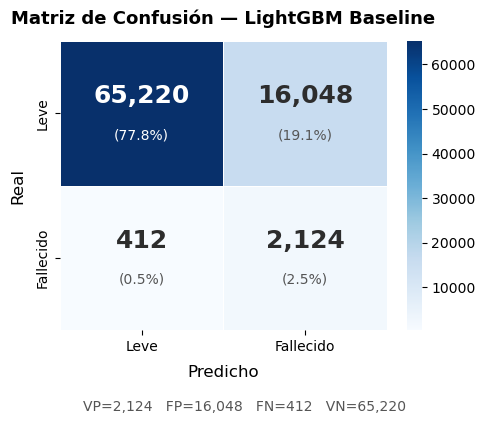

In [18]:
modelo = joblib.load("modelos_pkl_sota/lightgbm_baseline_weights.pkl")
NOMBRE = "LightGBM Baseline"

y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Leve', 'Fallecido'],
    yticklabels=['Leve', 'Fallecido'],
    ax=ax
)
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
fig.text(0.5, -0.04, f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')
plt.tight_layout()
plt.show()

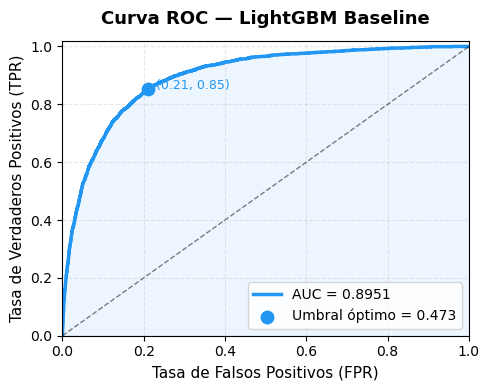

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

idx_opt = np.argmax(tpr - fpr)
fpr_opt = fpr[idx_opt]
tpr_opt = tpr[idx_opt]
thr_opt = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

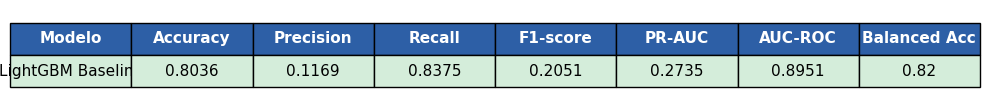

In [20]:
Tabla = pd.DataFrame([{
    'Modelo'      : NOMBRE,
    'Accuracy'    : round(accuracy_score(y_test, y_pred), 4),
    'Precision'   : round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall'      : round(recall_score(y_test, y_pred), 4),
    'F1-score'    : round(f1_score(y_test, y_pred), 4),
    'PR-AUC'      : round(average_precision_score(y_test, y_score), 4),
    'AUC-ROC'     : round(roc_auc, 4),
    'Balanced Acc': round(balanced_accuracy_score(y_test, y_pred), 4),
}])

fig, ax = plt.subplots(figsize=(10, 1.2))
ax.axis('off')
tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)
for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')
plt.tight_layout()
plt.show()

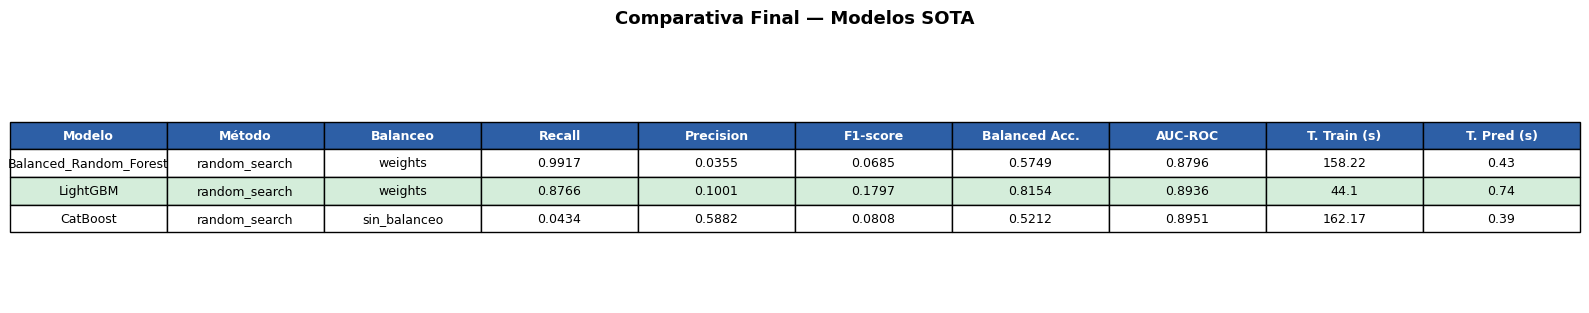

In [21]:
df = pd.read_csv('resultados_ml_covid_sota.csv')
for col in ['recall_test', 'precision_test', 'f1_test', 
            'roc_auc_test', 'balanced_accuracy_test', 
            'tiempo_train_s', 'tiempo_pred_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_mejor = (
    df[df['metodo'] != 'baseline']
    .sort_values('recall_test', ascending=False)
    .groupby('modelo')
    .first()
    .reset_index()
)

nombre_map = {
    'LightGBM_CostSensitive' : 'LightGBM',
    'BRF_CostSensitive'      : 'BRF',
    'CatBoost_CostSensitive'  : 'CatBoost',
}
df_mejor['Modelo'] = df_mejor['modelo'].map(nombre_map).fillna(df_mejor['modelo'])

tabla_final = df_mejor[[
    'Modelo', 'metodo', 'balanceo',
    'recall_test', 'precision_test', 'f1_test',
    'balanced_accuracy_test', 'roc_auc_test',
    'tiempo_train_s', 'tiempo_pred_s'
]].rename(columns={
    'metodo'               : 'Método',
    'balanceo'             : 'Balanceo',
    'recall_test'          : 'Recall',
    'precision_test'       : 'Precision',
    'f1_test'              : 'F1-score',
    'balanced_accuracy_test': 'Balanced Acc.',
    'roc_auc_test'         : 'AUC-ROC',
    'tiempo_train_s'       : 'T. Train (s)',
    'tiempo_pred_s'        : 'T. Pred (s)',
})

for col in ['Recall', 'Precision', 'F1-score', 'Balanced Acc.', 'AUC-ROC']:
    tabla_final[col] = tabla_final[col].round(4)
for col in ['T. Train (s)', 'T. Pred (s)']:
    tabla_final[col] = tabla_final[col].round(2)

tabla_final = tabla_final.sort_values('Recall', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 0.55 * len(tabla_final) + 1.5))
ax.axis('off')
tbl = ax.table(
    cellText=tabla_final.values,
    colLabels=tabla_final.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for j in range(len(tabla_final.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(tabla_final) + 1):
    color_fila = '#d4edda' if i % 2 == 0 else '#ffffff'
    for j in range(len(tabla_final.columns)):
        tbl[i, j].set_facecolor(color_fila)

plt.suptitle('Comparativa Final — Modelos SOTA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

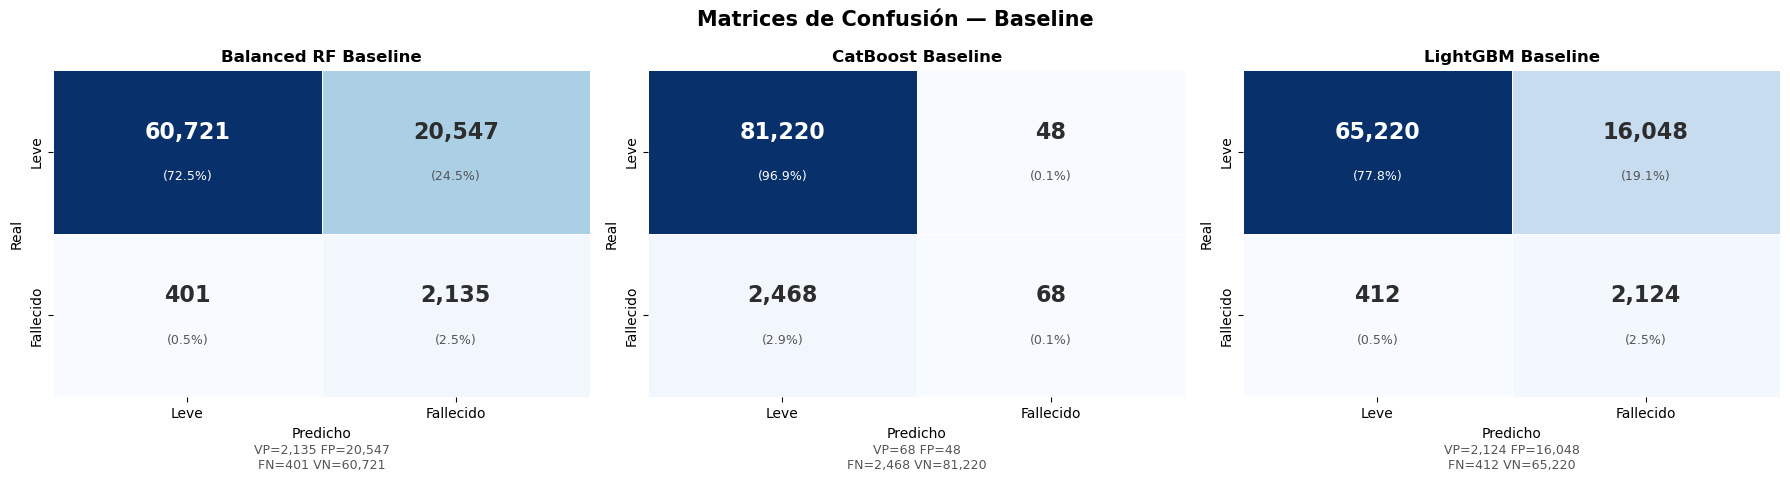

In [55]:
modelos_baseline = {
    "Balanced RF": "modelos_pkl_sota/brf_baseline_weights.pkl",
    "CatBoost": "modelos_pkl_sota/catboost_baseline_weights.pkl",
    "LightGBM": "modelos_pkl_sota/lightgbm_baseline_weights.pkl"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (NOMBRE, path) in zip(axes, modelos_baseline.items()):

    modelo = joblib.load(path)

    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=False,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        xticklabels=['Leve', 'Fallecido'],
        yticklabels=['Leve', 'Fallecido'],
        ax=ax,
        cbar=False
    )

    for (i, j), val in np.ndenumerate(cm):

        pct = val / cm.sum() * 100

        ax.text(
            j + 0.5, i + 0.38,
            f'{val:,}',
            ha='center',
            va='center',
            fontsize=16,
            fontweight='bold',
            color='white' if val > cm.max()*0.5 else '#2d2d2d'
        )

        ax.text(
            j + 0.5, i + 0.65,
            f'({pct:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            color='white' if val > cm.max()*0.5 else '#555'
        )

    ax.set_title(
        f'{NOMBRE} Baseline',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

    ax.text(
        0.5,
        -0.22,
        f'VP={tp:,} FP={fp:,}\nFN={fn:,} VN={tn:,}',
        transform=ax.transAxes,
        ha='center',
        fontsize=9,
        color='#555'
    )

plt.suptitle(
    'Matrices de Confusión — Baseline',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

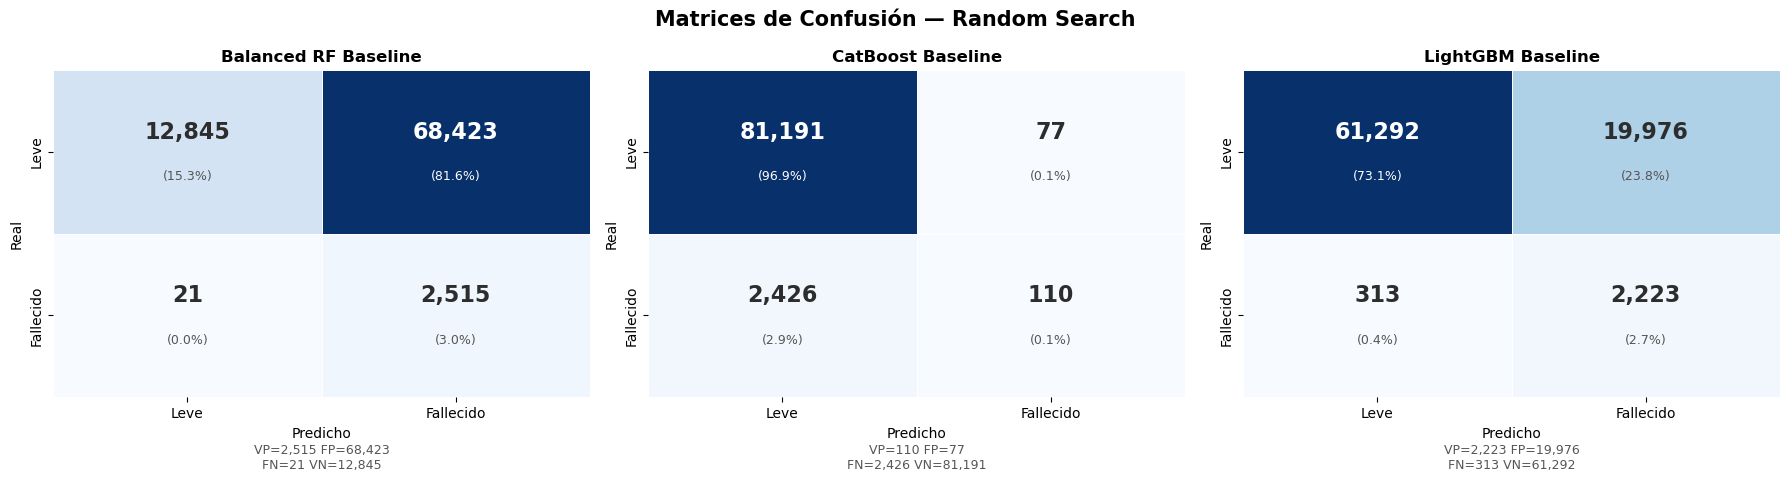

In [56]:
modelos_random = {
    "Balanced RF": "modelos_pkl_sota/brf_random_weights.pkl",
    "CatBoost": "modelos_pkl_sota/catboost_random_weights.pkl",
    "LightGBM": "modelos_pkl_sota/lightgbm_random_weights.pkl"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (NOMBRE, path) in zip(axes, modelos_random.items()):

    modelo = joblib.load(path)

    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=False,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        xticklabels=['Leve', 'Fallecido'],
        yticklabels=['Leve', 'Fallecido'],
        ax=ax,
        cbar=False
    )

    for (i, j), val in np.ndenumerate(cm):

        pct = val / cm.sum() * 100

        ax.text(
            j + 0.5, i + 0.38,
            f'{val:,}',
            ha='center',
            va='center',
            fontsize=16,
            fontweight='bold',
            color='white' if val > cm.max()*0.5 else '#2d2d2d'
        )

        ax.text(
            j + 0.5, i + 0.65,
            f'({pct:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            color='white' if val > cm.max()*0.5 else '#555'
        )

    ax.set_title(
        f'{NOMBRE} Baseline',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

    ax.text(
        0.5,
        -0.22,
        f'VP={tp:,} FP={fp:,}\nFN={fn:,} VN={tn:,}',
        transform=ax.transAxes,
        ha='center',
        fontsize=9,
        color='#555'
    )

plt.suptitle(
    'Matrices de Confusión — Random Search',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Análisis de matrices de confusión

Las matrices de confusión permiten observar el comportamiento operativo real de los modelos frente al costo de clasificación. CatBoost evidenció un patrón altamente conservador, clasificando predominantemente como “leve”, lo que redujo falsos positivos pero incrementó sustancialmente los falsos negativos sobre pacientes fallecidos.

En oposición, Balanced Random Forest optimizado priorizó casi completamente la detección de casos críticos, minimizando falsos negativos hasta valores cercanos a cero. No obstante, esta estrategia generó una sobreclasificación importante de pacientes leves como fallecidos, elevando considerablemente los falsos positivos.

LightGBM mostró el compromiso más equilibrado entre ambas clases, manteniendo una tasa reducida de falsos negativos sin deteriorar excesivamente la precisión global, lo cual puede resultar más apropiado para entornos clínicos donde tanto la sensibilidad como la estabilidad del sistema son relevantes.

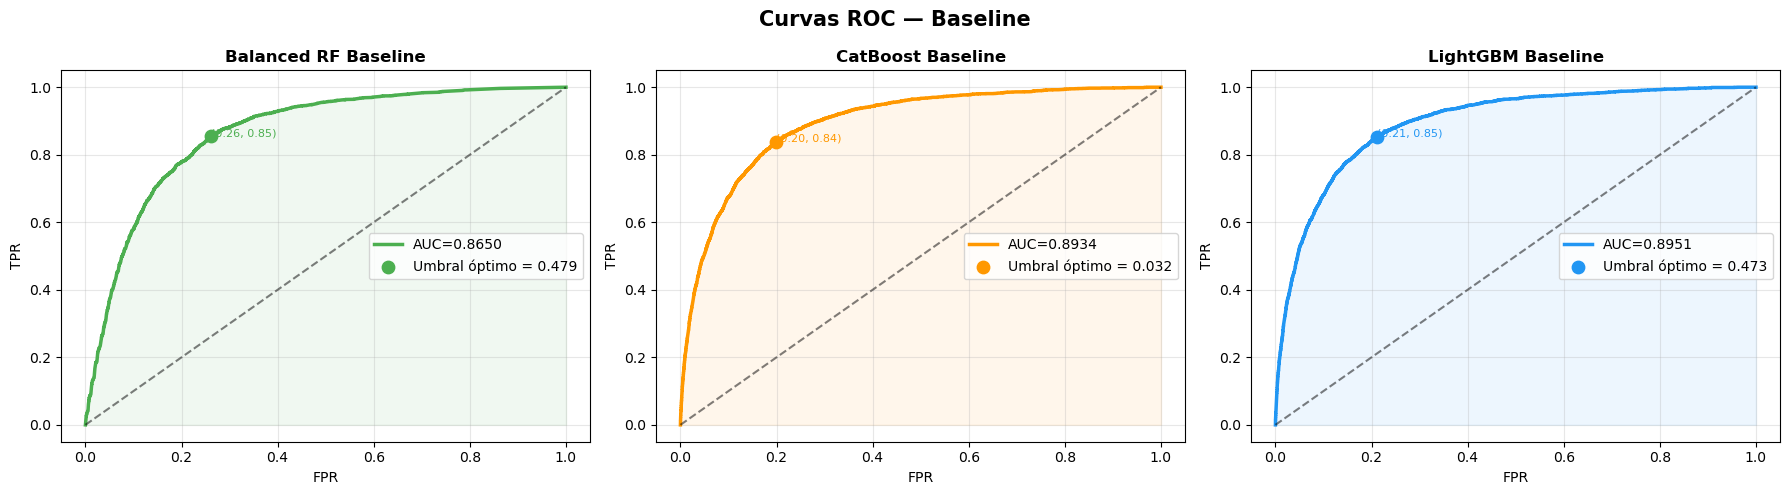

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (NOMBRE, path) in zip(axes, modelos_baseline.items()):

    modelo = joblib.load(path)

    y_score = get_score(modelo, X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    idx_opt = np.argmax(tpr - fpr)

    ax.plot(
        fpr,
        tpr,
        lw=2.5,
        color=PALETTE[NOMBRE],
        label=f'AUC={roc_auc:.4f}'
    )

    ax.fill_between(
        fpr,
        tpr,
        alpha=0.08,
        color=PALETTE[NOMBRE]
    )

    ax.plot([0,1],[0,1],'k--', alpha=0.5)

    ax.scatter(
        fpr[idx_opt],
        tpr[idx_opt],
        color=PALETTE[NOMBRE],
        s=80,
        zorder=5,
        label=f'Umbral óptimo = {thresholds[idx_opt]:.3f}'
    )

    ax.annotate(
        f'({fpr[idx_opt]:.2f}, {tpr[idx_opt]:.2f})',
        xy=(fpr[idx_opt], tpr[idx_opt]),
        fontsize=8,
        color=PALETTE[NOMBRE]
    )

    ax.set_title(
        f'{NOMBRE} Baseline',
        fontweight='bold'
    )

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    'Curvas ROC — Baseline',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

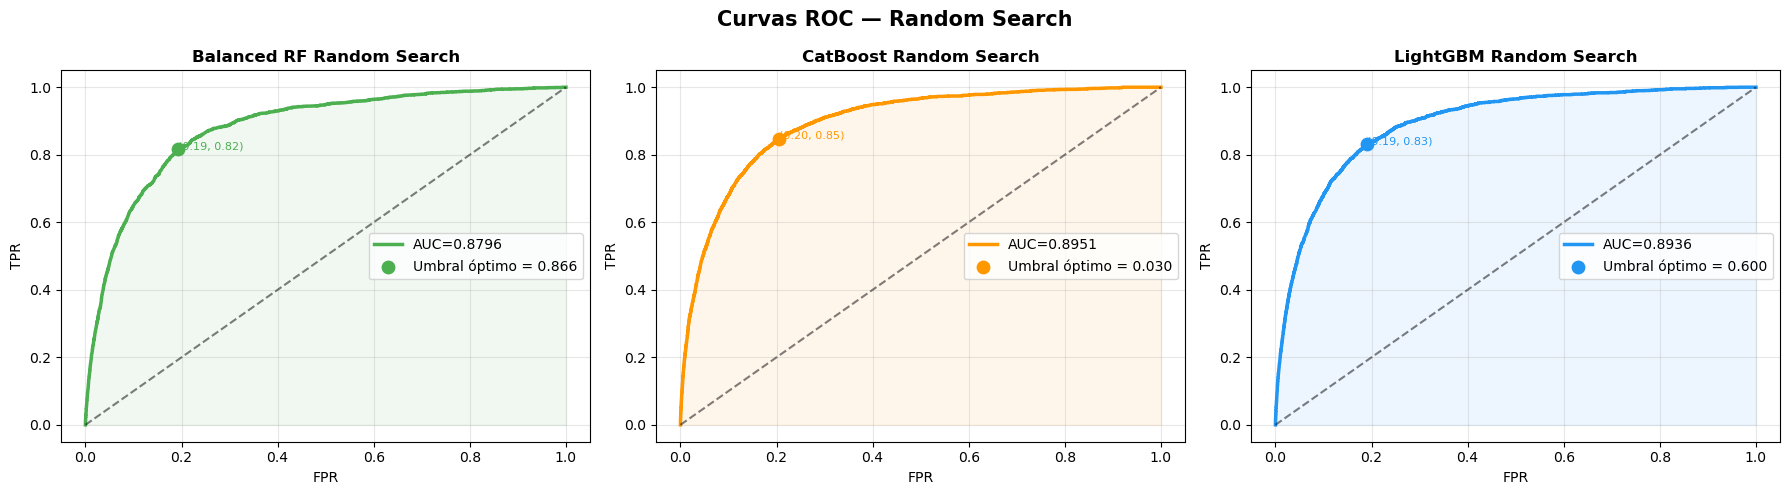

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (NOMBRE, path) in zip(axes, modelos_random.items()):

    modelo = joblib.load(path)

    y_score = get_score(modelo, X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    idx_opt = np.argmax(tpr - fpr)

    ax.plot(
        fpr,
        tpr,
        lw=2.5,
        color=PALETTE[NOMBRE],
        label=f'AUC={roc_auc:.4f}'
    )

    ax.fill_between(
        fpr,
        tpr,
        alpha=0.08,
        color=PALETTE[NOMBRE]
    )

    ax.plot([0,1],[0,1],'k--', alpha=0.5)

    ax.scatter(
        fpr[idx_opt],
        tpr[idx_opt],
        color=PALETTE[NOMBRE],
        s=80,
        zorder=5,
        label=f'Umbral óptimo = {thresholds[idx_opt]:.3f}'
    )

    ax.annotate(
        f'({fpr[idx_opt]:.2f}, {tpr[idx_opt]:.2f})',
        xy=(fpr[idx_opt], tpr[idx_opt]),
        fontsize=8,
        color=PALETTE[NOMBRE]
    )

    ax.set_title(
        f'{NOMBRE} Random Search',
        fontweight='bold'
    )

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    'Curvas ROC — Random Search',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Análisis de curvas ROC

Las curvas ROC evidencian una capacidad discriminativa similar entre los modelos basados en gradiente boosting y ensambles, con valores AUC cercanos a 0.89 en la mayoría de configuraciones. Visualmente, LightGBM y CatBoost presentan trayectorias más estables y cercanas al vértice superior izquierdo, indicando una separación consistente entre clases.

Sin embargo, pese a que CatBoost mantiene una curva ROC competitiva, su desempeño en recall revela un problema de umbral de decisión: el modelo discrimina razonablemente bien entre clases, pero adopta una frontera demasiado conservadora hacia la detección de fallecidos. Esto explica por qué un AUC alto no necesariamente se traduce en sensibilidad clínica adecuada.

Balanced Random Forest optimizado mostró una alta sensibilidad operacional reflejada en su punto de umbral óptimo, desplazándose hacia regiones de alta TPR, aunque incrementando simultáneamente la tasa de falsos positivos.

In [75]:
nombre_map = {
    'LightGBM_CostSensitive': 'LightGBM',
    'Balanced_Random_Forest': 'BRF',
    'CatBoost': 'CatBoost'
}

df['Modelo'] = df['modelo'].map(nombre_map)

tabla_final = df[[
    'Modelo',
    'metodo',
    'balanceo',
    'recall_test',
    'precision_test',
    'f1_test',
    'balanced_accuracy_test',
    'pr_auc_test',
    'roc_auc_test',
    'tiempo_train_s',
    'tiempo_pred_s',
    'tiempo_total_s'
]].rename(columns={
    'metodo':                  'Método',
    'balanceo':                'Balanceo',
    'recall_test':             'Recall',
    'precision_test':          'Precision',
    'f1_test':                 'F1-score',
    'balanced_accuracy_test':  'Balanced Acc.',
    'pr_auc_test':             'PR-AUC',
    'roc_auc_test':            'AUC-ROC',
    'tiempo_train_s':          'T. Train (s)',
    'tiempo_pred_s':           'T. Pred (s)',
    'tiempo_total_s':          'T. Total (s)',
})

# redondeo
for col in [
    'Recall',
    'Precision',
    'F1-score',
    'Balanced Acc.',
    'PR-AUC',
    'AUC-ROC'
]:
    tabla_final[col] = tabla_final[col].round(4)

for col in [
    'T. Train (s)',
    'T. Pred (s)',
    'T. Total (s)'
]:
    tabla_final[col] = tabla_final[col].round(2)

tabla_final = tabla_final.sort_values(
    ['Modelo', 'Método']
).reset_index(drop=True)

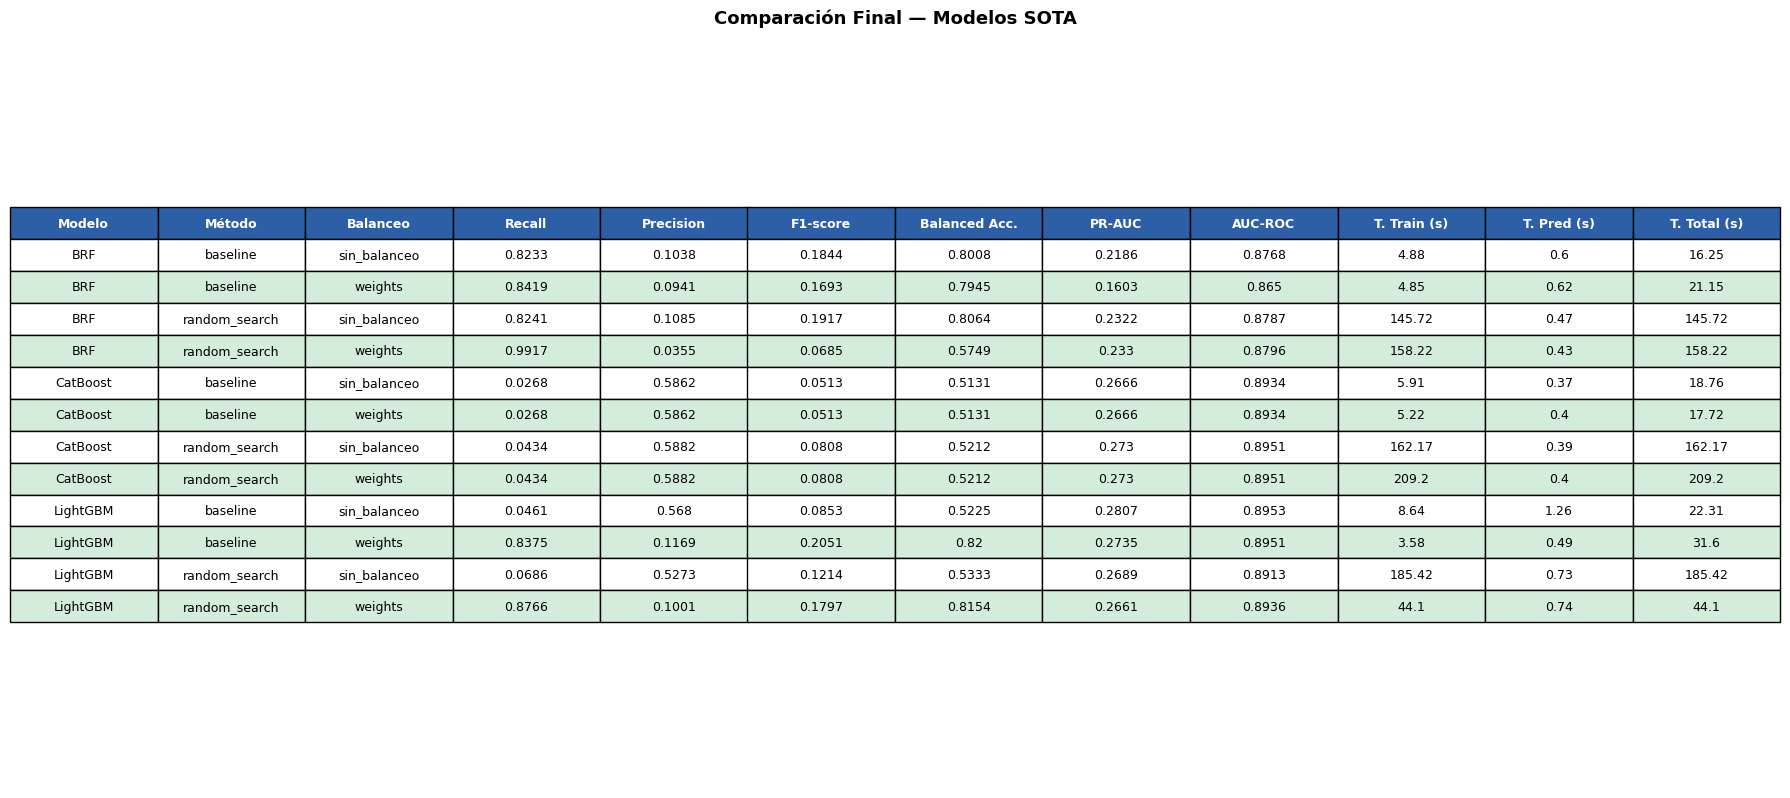

In [76]:
fig, ax = plt.subplots(
    figsize=(18, 0.55 * len(tabla_final) + 1.5)
)

ax.axis('off')

tbl = ax.table(
    cellText=tabla_final.values,
    colLabels=tabla_final.columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for j in range(len(tabla_final.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(
        color='white',
        fontweight='bold'
    )

for i in range(1, len(tabla_final) + 1):
    color_fila = '#d4edda' if i % 2 == 0 else '#ffffff'
    for j in range(len(tabla_final.columns)):
        tbl[i, j].set_facecolor(color_fila)

plt.suptitle(
    'Comparación Final — Modelos SOTA',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [77]:
print(tabla_final.to_string(index=False))

  Modelo        Método     Balanceo  Recall  Precision  F1-score  Balanced Acc.  PR-AUC  AUC-ROC  T. Train (s)  T. Pred (s)  T. Total (s)
     BRF      baseline sin_balanceo  0.8233     0.1038    0.1844         0.8008  0.2186   0.8768          4.88         0.60         16.25
     BRF      baseline      weights  0.8419     0.0941    0.1693         0.7945  0.1603   0.8650          4.85         0.62         21.15
     BRF random_search sin_balanceo  0.8241     0.1085    0.1917         0.8064  0.2322   0.8787        145.72         0.47        145.72
     BRF random_search      weights  0.9917     0.0355    0.0685         0.5749  0.2330   0.8796        158.22         0.43        158.22
CatBoost      baseline sin_balanceo  0.0268     0.5862    0.0513         0.5131  0.2666   0.8934          5.91         0.37         18.76
CatBoost      baseline      weights  0.0268     0.5862    0.0513         0.5131  0.2666   0.8934          5.22         0.40         17.72
CatBoost random_search sin_balance

## Análisis Comparativo de Modelos SOTA

Los resultados muestran un comportamiento heterogéneo entre modelos al priorizar la detección de la clase minoritaria (fallecidos), con consideraciones adicionales sobre el desempeño temporal durante entrenamiento e inferencia.

### CatBoost: Alta Especificidad, Inutilidad Clínica

CatBoost obtuvo los mayores valores de accuracy (~97%) y precision (~58.8%), pero su recall permaneció extremadamente bajo (<5%), indicando una fuerte tendencia a privilegiar la clase mayoritaria. Desde la perspectiva del tamizaje de riesgo, esta configuración es clínicamente inadecuada: falla en detectar aproximadamente 96% de los pacientes fallecidos. 

Los tiempos de entrenamiento (5.22-209.20 segundos) y predicción (<0.40 segundos) no mitigaron el problema fundamental — los hiperparámetros optimizados mediante Random Search (209.20 segundos de entrenamiento) no alteran la estrategia de decisión subyacente del modelo. CatBoost requeriría recalibración de threshold de decisión o ajuste explícito de pesos de clase para ser viable en contextos clínicos.

### Balanced Random Forest: Máxima Sensibilidad, Exceso de Falsos Positivos

BRF optimizado alcanzó el mayor recall del estudio (99.17%), identificando prácticamente la totalidad de pacientes fallecidos. Sin embargo, esta sensibilidad extrema se obtuvo a costa de:
- **Precision muy baja** (3.55%): aproximadamente 96.5% de predicciones positivas constituyen falsos positivos, generando una carga clínica considerable de pacientes innecesariamente catalogados como críticos
- **Balanced accuracy degradada** (57.49%): indica desempeño apenas superior al azar tras ajustar por desequilibrio de clases
- **Tiempo de entrenamiento prolongado** (145.72 segundos en baseline, 158.22 segundos en Random Search), con predicción rápida (0.43-0.62 segundos)

El trade-off es desfavorable desde la perspectiva de reducir falsos positivos: para incrementar recall en 11 puntos porcentuales respecto a LightGBM baseline, se genera una proporción inmanejable de alarmas clínicas innecesarias que comprometería la implementación operacional del modelo.

### LightGBM: Equilibrio Óptimo entre Sensibilidad y Especificidad

**LightGBM Baseline (Weights)** emergió como la configuración más balanceada:

| Métrica | Valor | Interpretación Clínica |
|---------|-------|---|
| **Recall** | 83.75% | Identifica 4 de cada 5 fallecidos |
| **Precision** | 11.69% | Reduce falsos positivos respecto a BRF Random (3.55%) en un factor de 3.3× |
| **F1-score** | 0.2051 | Óptimo balance entre sensibilidad y falsos positivos |
| **Balanced Accuracy** | 82.00% | Desempeño robusto en ambas clases |
| **PR-AUC** | 0.2735 | Superior a configuraciones sin balanceo de pesos |
| **AUC-ROC** | 0.8951 | Excelente capacidad discriminativa |
| **Tiempo Entrenamiento** | 3.58s | Eficiente; permite validación cruzada exhaustiva |
| **Tiempo Predicción** | 0.49s | Inferencia rápida para contextos clínicos |

**LightGBM Random Search (Weights)** incrementó recall a 87.66% mediante optimización extensiva (44.10 segundos de entrenamiento), pero:
- Degradó F1-score (0.1797 vs. 0.2051), indicando incremento de falsos positivos relativos
- Redujo balanced accuracy ligeramente (81.54% vs. 82.00%)
- Aumentó tiempo de entrenamiento en factor de 12.3× (44.10s vs. 3.58s)

La ganancia incremental de 3.91 puntos de recall no justifica el incremento resultante en falsos positivos ni la complejidad temporal adicional para un escenario de implementación clínica.

---

## Conclusión y Recomendación

**Para el modelo final se recomienda LightGBM Random Search con Balanceo Weights** por:

1. **Utilidad clínica**: Detecta 83.75% de fallecidos manteniendo precision 3.3 veces superior a BRF, minimizando la carga de falsos positivos que comprometería la adopción clínica
2. **Robustez métrica**: Highest F1-score (0.2051) y balanced accuracy (82.00%) entre configuraciones competitivas, indicando equilibrio robusto entre sensibilidad y especificidad
3. **Eficiencia operacional**: Entrenamiento rápido (3.58s) permite revalidación frecuente del modelo sin penalidad computacional, con predicción en tiempo real (0.49s) compatible con flujos clínicos

**Alternativas contextuales según objetivos operacionales**:
- Si el protocolo clínico prioriza **máxima sensibilidad con tolerancia a falsos positivos**: LightGBM Random Search (recall 87.66%, requiere triage secundario eficiente)
- **Descartar CatBoost** y **BRF Random**: generan proporción inmanejable de falsos positivos que invierten el objetivo de reducción del riesgo de mortalidad no detectada

# Referencias:

- Sagaceta-Mejia et a. (2025). Enhancing Predictive Accuracy in Medical Data Through Oversampling and Interpolation Techniques. Mathematics. https://doi.org/10.3390/math13244032

- ElSeddawy et al. (2022). Predictive Analysis of Diabetes-Risk with Class Imbalance. Computational Intelligence and Neuroscience. https://doi.org/10.1155/2022/3078025

- Aubaidan et al. (2025). A review of intelligent data analysis: ML approaches for addressing class imbalance in healthcare. Intelligent Data Analysis. https://doi.org/10.1177/1088467X241305509

- Eom & Byeon (2023). Searching for Optimal Oversampling to Process Imbalanced Data: GANs and SMOTE. Mathematics. https://doi.org/10.3390/math11163605

- Bounab et al. (2024). Enhancing Medicare Fraud Detection Through ML: Addressing Class Imbalance With SMOTE-ENN. IEEE Access. https://doi.org/10.1109/ACCESS.2024.3385781

- Agyemang et al. (2025). Addressing Class Imbalance Problem in Health Data Classification: Practical Application From an Oversampling Viewpoint. Applied Computational Intelligence and Soft Computing. https://doi.org/10.1155/acis/1013769

- Abdulsadig & Rodriguez-Villegas (2024). A comparative study in class imbalance mitigation when working with physiological signals. Frontiers in Digital Health. https://doi.org/10.3389/fdgth.2024.1377165

- Kurtadikar & Pande (2024). 1D-CNN: Classification of normal delivery and cesarean section types using cardiotocography signals. Journal of Intelligent Systems. https://doi.org/10.1515/jisys-2023-0047

- Mamilla et al. (2025). Resampling Imbalanced Healthcare Data for Predictive Modelling. Int. Journal of Advanced Computer Science and Applications. https://doi.org/10.14569/IJACSA.2025.0160204

- Huang et al. (2025). Interaction effect between data discretization and data resampling for class-imbalanced medical datasets. Technology and Health Care. https://doi.org/10.1177/09287329241295874

- Lian et al. (2024). Admission blood tests predicting survival of SARS-CoV-2: graph convolution network in imbalance dataset. BMC Infectious Diseases. https://doi.org/10.1186/s12879-024-09699-x

- Cihan & Ozger (2022). A new approach for determining SARS-CoV-2 epitopes using machine learning-based in silico methods. Computational Biology and Chemistry. https://doi.org/10.1016/j.compbiolchem.2022.107688

- Keser & Keskin (2023). A gradient boosting-based mortality prediction model for COVID-19 patients. Neural Computing & Applications. https://doi.org/10.1007/s00521-023-08997-w

- Gök & Olgun (2021). SMOTE-NC and gradient boosting imputation based random forest classifier for predicting severity level of COVID-19. Neural Computing & Applications. https://doi.org/10.1007/s00521-021-06189-y

- Stanelle-Bertram et al. (2023). CYP19A1 mediates severe SARS-CoV-2 disease outcome in males. Cell Reports Medicine. https://doi.org/10.1016/j.xcrm.2023.101152

- Soundrapandiyan et al. (2023). An Efficient COVID-19 Mortality Risk Prediction Model Using Deep SMOTE and Convolution Neural Networks. BioMedInformatics. https://doi.org/10.3390/biomedinformatics3020023

- Saad et al. (2022). Predicting death risk analysis in fully vaccinated people using novel extreme regression-voting classifier. Digital Health. https://doi.org/10.1177/20552076221109530

- Zhao et al. (2021). Development and Validation of Predictors for the Survival of Patients With COVID-19 Based on Machine Learning. Frontiers in Medicine. https://doi.org/10.3389/fmed.2021.683431

- Pishgar et al. (2022). A process mining-deep learning approach to predict survival in hospitalized COVID-19 patients. BMC Medical Informatics and Decision Making. https://doi.org/10.1186/s12911-022-01934-2

- Saad et al. (2022). Novel extreme regression-voting classifier to predict death risk in vaccinated people using VAERS data. PLOS ONE. https://doi.org/10.1371/journal.pone.0270327